<a href="https://colab.research.google.com/github/Abhijeet141022/Quantum-Techonology-Course/blob/main/grover_algorithm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install qiskit

In [ ]:
pip install qiskit-ibm-runtime

In [ ]:
pip install -U matplotlib pylatexenc

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 73.4 MB/s eta 0:00:00
  Attempting uninstall: matplotlib
    Found existing installation: matplotlib 3.10.0
    Uninstalling matplotlib-3.10.0:
      Successfully uninstalled matplotlib-3.10.0


## Setup

In [ ]:
import math
from qiskit import QuantumCircuit
from qiskit.circuit.library import grover_operator, MCMTGate, ZGate
from qiskit.visualization import plot_distribution
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit_ibm_runtime import SamplerV2 as Sampler

In [ ]:
def grover_oracle(marked_states):
    """Build a Grover oracle for multiple marked states

    Here we assume all input marked states have the same number of bits

    Parameters:
        marked_states (str or list): Marked states of oracle

    Returns:
        QuantumCircuit: Quantum circuit representing Grover oracle
    """
    if not isinstance(marked_states, list):
        marked_states = [marked_states]
    num_qubitsi = len(marked_states[0])  # Compute the number of qubits in circuit
    qc = QuantumCircuit(num_qubits)
    for target in marked_states: # Mark each target state in the input list
        rev_target = target[::-1] # Flip target bit-string to match Qiskit bit-ordering
        zero_inds = [ # Find the indices of all the '0' elements in bit-string
            ind
            for ind in range(num_qubits)
             if rev_target.startswith("0", ind)
        ]
        if zero_inds: # Add a multi-controlled Z-gate with pre- and post-applied X-gates where the target bit-string has a '0' entry
            qc.x(zero_inds)
        qc.compose(MCMTGate(ZGate(), num_qubits - 1, 1), inplace=True)
        if zero_inds:
            qc.x(zero_inds)
    return qc

## Specific Grover instance

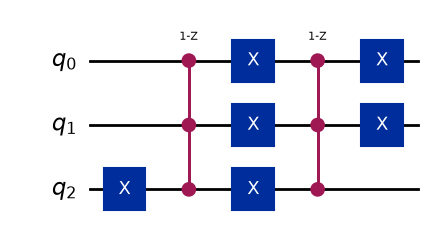

In [ ]:
marked_states = ["011", "100"]

oracle = grover_oracle(marked_states)
oracle.draw(output="mpl", style="iqp")

In [ ]:
marked_states = ["011", "100"]

oracle = grover_oracle(marked_states)
print(oracle.draw(output="text"))

           1-Z ┌───┐ 1-Z ┌───┐
q_0: ───────■──┤ X ├──■──┤ X ├
            │  ├───┤  │  ├───┤
q_1: ───────■──┤ X ├──■──┤ X ├
     ┌───┐  │  ├───┤  │  └───┘
q_2: ┤ X ├──■──┤ X ├──■───────
     └───┘     └───┘          


## Grover operator

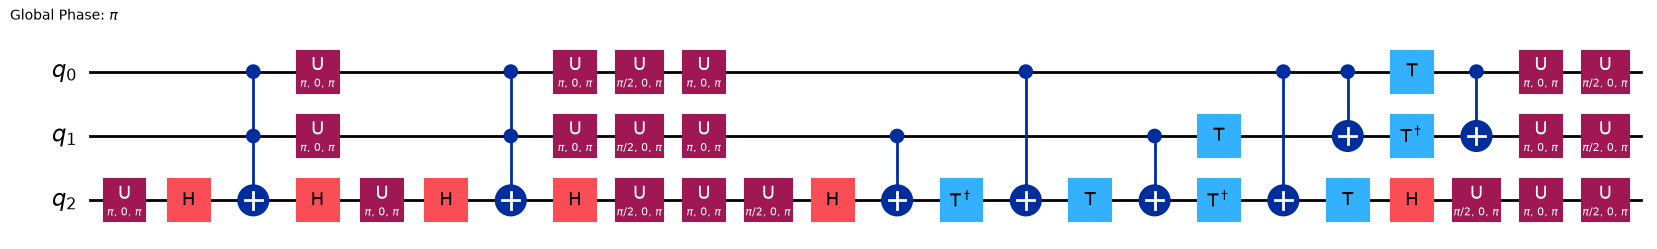

In [ ]:
grover_op = grover_operator(oracle)
grover_op.decompose().draw(output="mpl", style="iqp")

In [ ]:
optimal_num_iterations = math.floor(
    math.pi
    / (4 * math.asin(math.sqrt(len(marked_states) / 2**grover_op.num_qubits)))
)

## Full Grover circuit

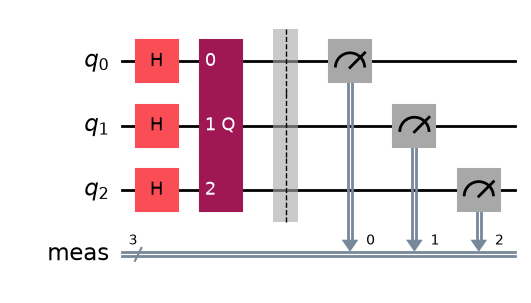

In [ ]:
qc = QuantumCircuit(grover_op.num_qubits)
# Create even superposition of all basis states
qc.h(range(grover_op.num_qubits))
# Apply Grover operator the optimal number of times
qc.compose(grover_op.power(optimal_num_iterations), inplace=True)
# Measure all qubits
qc.measure_all()
qc.draw(output="mpl", style="iqp")

## Optimize problem for quantum hardware execution

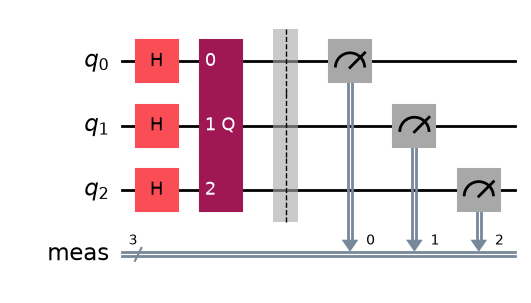

In [ ]:
pm = generate_preset_pass_manager(optimization_level=3)
circuit_isa = pm.run(qc)
circuit_isa.draw(output="mpl", idle_wires=False, style="iqp")

## Execute using Qiskit primitives

In [ ]:
from qiskit.primitives import StatevectorSampler

sampler = StatevectorSampler()
result = sampler.run([circuit_isa], shots=10_000).result()
dist = result[0].data.meas.get_counts()

## Post-process and return result in desired classical format

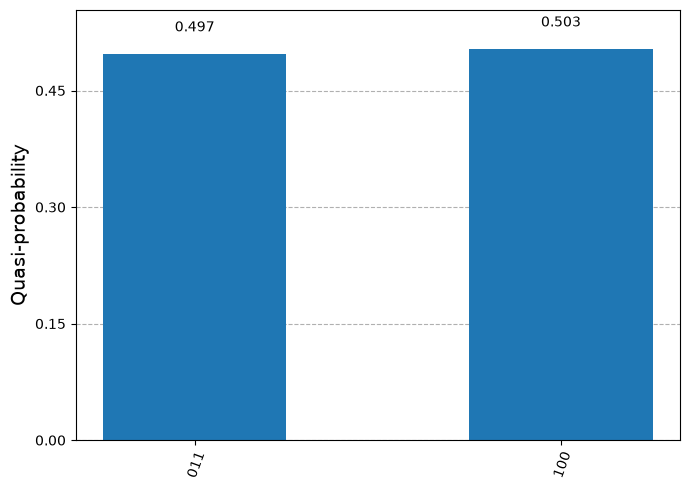

In [ ]:
plot_distribution(dist)

## Hardware example

In [ ]:
from qiskit import QuantumCircuit, transpile
from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2

# Login once
QiskitRuntimeService.save_account(
    channel="ibm_quantum_platform",
    token="QmdWblfWNrDdlhjc4qP3CBLxFAedrOJsrGiybF9aF1Rd",
    overwrite=True
)

service = QiskitRuntimeService()

backend = service.least_busy(
    simulator=False,
    operational=True
)

qiskit_runtime_service.__init__:WARNING:2026-09-22 12:57:55,009: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService(). Alternatively, pass instance='auto' or save it to your account for auto-selection without warning.
qiskit_runtime_service.backends:WARNING:2026-09-22 12:57:55,382: Loading instance: open-instance, plan: open
qiskit_runtime_service.backends:WARNING:2026-09-22 12:57:57,727: Using instance: open-instance, plan: open


qiskit_runtime_service.__init__:WARNING:2026-09-22 12:58:03,602: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService(). Alternatively, pass instance='auto' or save it to your account for auto-selection without warning.
qiskit_runtime_service.backends:WARNING:2026-09-22 12:58:03,891: Loading instance: open-instance, plan: open
qiskit_runtime_service.backends:WARNING:2026-09-22 12:58:06,669: Using instance: open-instance, plan: open


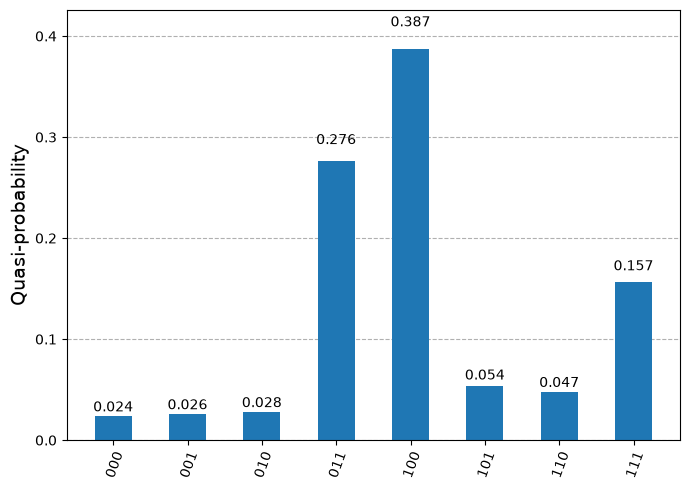

In [ ]:
# Step 1
marked_states = ["011", "100"]

oracle = grover_oracle(marked_states)
grover_op = grover_operator(oracle)

optimal_num_iterations = math.floor(
    math.pi
    / (4 * math.asin(math.sqrt(len(marked_states) / 2**grover_op.num_qubits)))
)

qc = QuantumCircuit(grover_op.num_qubits)
qc.h(range(grover_op.num_qubits))
qc.compose(grover_op.power(optimal_num_iterations), inplace=True)
qc.measure_all()

# Step 2
service = QiskitRuntimeService()
backend = service.least_busy(
    operational=True, simulator=False, min_num_qubits=127
)

target = backend.target
pm = generate_preset_pass_manager(target=target, optimization_level=3)
circuit_isa = pm.run(qc)

# Step 3
sampler = Sampler(mode=backend)
sampler.options.default_shots = 10_000
sampler.options.environment.job_tags = ["TUT-GA"]
result = sampler.run([circuit_isa]).result()
dist = result[0].data.meas.get_counts()

# Step 4
plot_distribution(dist)

qiskit_runtime_service.backends:WARNING:2026-09-22 12:58:23,801: Loading instance: open-instance, plan: open
qiskit_runtime_service.backends:WARNING:2026-09-22 12:58:24,776: Using instance: open-instance, plan: open


n=3: optimal_iters=2, 2Q depth=39
n=4: optimal_iters=3, 2Q depth=113
n=5: optimal_iters=4, 2Q depth=455
n=6: optimal_iters=6, 2Q depth=1507
n=7: optimal_iters=8, 2Q depth=3304
n=8: optimal_iters=12, 2Q depth=7588
n=9: optimal_iters=17, 2Q depth=13015


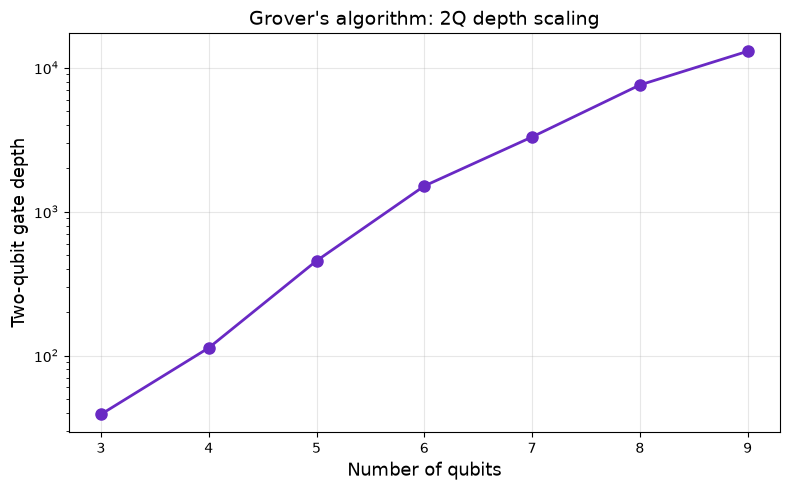

In [ ]:
import matplotlib.pyplot as plt

num_qubits_list = list(range(3, 10))
two_q_depths = []
backend = service.least_busy(
    operational=True, simulator=False, min_num_qubits=127
)
for n in num_qubits_list:
    # Mark a single state for simplicity
    marked = ["1" * n]
    oracle_n = grover_oracle(marked)
    grover_op_n = grover_operator(oracle_n)

    # Optimal number of iterations
    num_iters = math.floor(
        math.pi / (4 * math.asin(math.sqrt(len(marked) / 2**n)))
    )

    # Build the full Grover circuit
    qc_n = QuantumCircuit(n)
    qc_n.h(range(n))
    qc_n.compose(grover_op_n.power(num_iters), inplace=True)
    qc_n.measure_all()

    # Transpile to a basis gate set and count 2Q depth
    pm_n = generate_preset_pass_manager(backend=backend, optimization_level=3)
    qc_transpiled = pm_n.run(qc_n)

    # Compute depth restricted to 2-qubit operations
    depth_2q = qc_transpiled.depth(lambda x: x.operation.num_qubits == 2)

    two_q_depths.append(depth_2q)
    print(f"n={n}: optimal_iters={num_iters}, 2Q depth={depth_2q}")

# Plot
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(
    num_qubits_list,
    two_q_depths,
    "o-",
    linewidth=2,
    markersize=8,
    color="#6929C4",
)
ax.set_xlabel("Number of qubits", fontsize=13)
ax.set_ylabel("Two-qubit gate depth", fontsize=13)
ax.set_title("Grover's algorithm: 2Q depth scaling", fontsize=14)
ax.set_yscale("log")
ax.grid(True, alpha=0.3)
ax.set_xticks(num_qubits_list)
plt.tight_layout()
plt.show()